
dataset loaded successfully
  rows    : 17
  columns : 3
  columns : ['source_franchise', 'target_franchise', 'communication_count']

source_franchise    target_franchise      communication_count
Franchise_A         Franchise_B                            11
Franchise_A         Franchise_C                             7
Franchise_B         Franchise_D                             9
Franchise_B         Franchise_E                             6
Franchise_C         Franchise_D                            10
Franchise_C         Franchise_F                             5
Franchise_D         Franchise_G                            12
Franchise_D         Franchise_H                             4
Franchise_E         Franchise_H                             8
Franchise_E         Franchise_I                             6
Franchise_F         Franchise_I                             4
Franchise_G         Franchise_J                            13
Franchise_G         Franchise_K                            

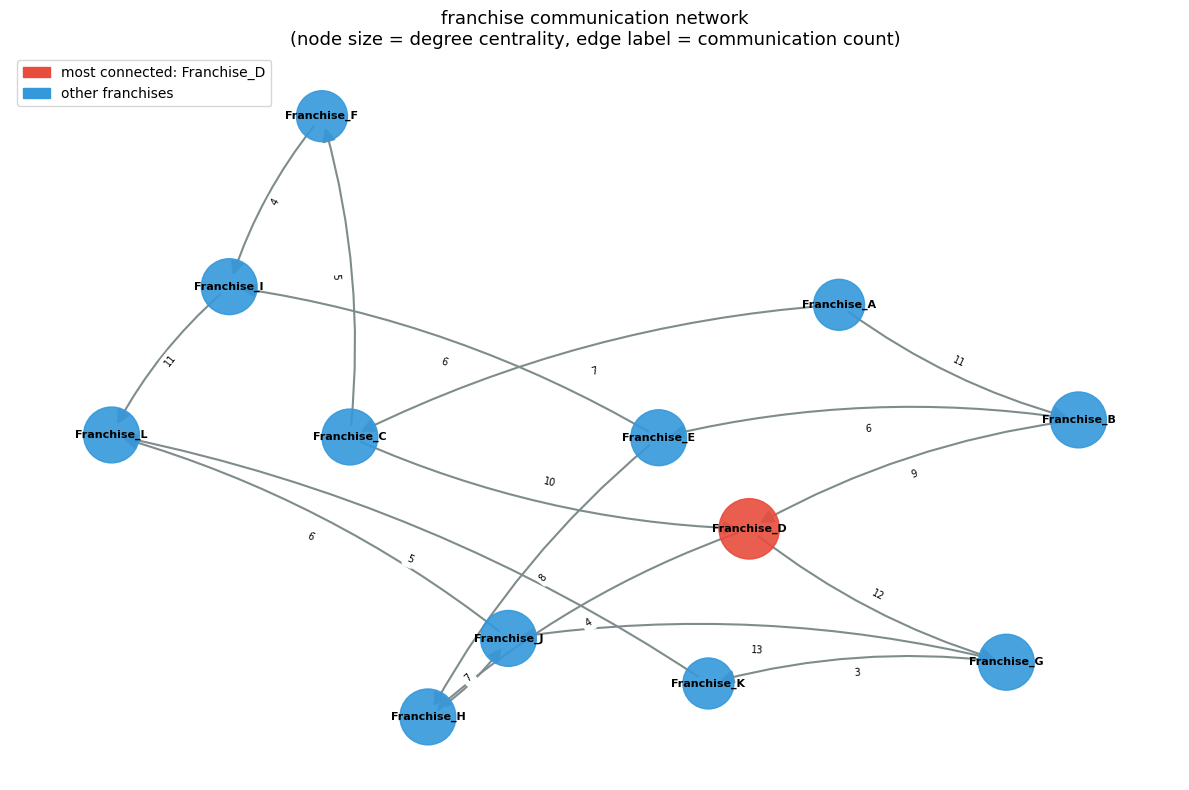

interactive pyvis network saved to data/q2_interactive_network.html


In [4]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tabulate import tabulate
from pyvis.network import Network


# Defining a helper function to print any DataFrame as a clean left aligned table
# Using tabulate with tablefmt plain so there are no borders just clean spacing
# Using showindex False to hide the default row numbers on the left
def print_table(df):
    print(tabulate(df, headers=df.columns, tablefmt='plain', showindex=False))


# Step 1: loading the Excel file into Python

# Reading the Excel file from the data folder and loading it into a pandas DataFrame
# Using data/ before the filename because the Excel file is saved inside the data folder
df = pd.read_excel('data/franchise_network.xlsx')

print()
print('dataset loaded successfully')
print(f'  rows    : {df.shape[0]}')
print(f'  columns : {df.shape[1]}')
print(f'  columns : {df.columns.tolist()}')
print()
print_table(df)
print()


# Step 2: creating a directed weighted graph from the dataset

# Initializing an empty directed graph using DiGraph because communication
# flows in one direction from source franchise to target franchise
G = nx.DiGraph()

# Adding edges from each row in the dataset
# Using weight as the communication count so heavier edges mean more communication
for _, row in df.iterrows():
    G.add_edge(row['source_franchise'], row['target_franchise'],
               weight=int(row['communication_count']))


# Step 3: printing the list of nodes and edges

print('list of nodes')
print()
# Sorting nodes alphabetically so they print in a clean readable order
nodes_df = pd.DataFrame(sorted(G.nodes()), columns=['franchise'])
print_table(nodes_df)
print()

print('list of edges')
print()
# Converting each edge and its weight into a row for clean tabular display
edges_df = pd.DataFrame(
    [(u, v, d['weight']) for u, v, d in G.edges(data=True)],
    columns=['source', 'target', 'communication_count']
)
print_table(edges_df)
print()


# Step 4: reporting the total number of nodes and edges in the network

print('network summary')
print(f'  total nodes : {G.number_of_nodes()}')
print(f'  total edges : {G.number_of_edges()}')
print()


# Step 5: computing the in-degree and out-degree of each franchise branch

# In-degree counts how many branches are sending communication into this branch
# Out-degree counts how many branches this branch is sending communication out to
deg_df = pd.DataFrame({
    'franchise' : list(G.nodes()),
    'in_degree' : [G.in_degree(n)  for n in G.nodes()],
    'out_degree': [G.out_degree(n) for n in G.nodes()]
}).sort_values('franchise').reset_index(drop=True)

print('in-degree and out-degree of each franchise')
print()
print_table(deg_df)
print()


# Step 6: computing degree centrality and betweenness centrality of each franchise branch

# Degree centrality measures how connected a node is relative to all other nodes
# a higher value means the franchise communicates with more branches
dc = nx.degree_centrality(G)

# Betweenness centrality measures how often a node acts as a bridge on shortest paths
# a higher value means more communication routes pass through this franchise
bc = nx.betweenness_centrality(G, weight='weight')

cen_df = pd.DataFrame({
    'franchise'              : list(dc.keys()),
    'degree_centrality'      : [round(v, 4) for v in dc.values()],
    'betweenness_centrality' : [round(bc[n], 4) for n in dc.keys()]
}).sort_values('franchise').reset_index(drop=True)

print('degree centrality and betweenness centrality')
print()
print_table(cen_df)
print()


# Step 7: identifying the most connected and most important bridge franchise branch

# Finding the node with the highest degree centrality as the most connected branch
most_connected = max(dc, key=dc.get)

# Finding the node with the highest betweenness centrality as the most important bridge
most_bridge = max(bc, key=bc.get)

print('identifying key franchise branches')
print(f'  most connected franchise  : {most_connected} (degree centrality = {round(dc[most_connected], 4)})')
print(f'  most important bridge     : {most_bridge} (betweenness centrality = {round(bc[most_bridge], 4)})')
print()


# Step 8: finding the shortest path from Franchise_A to Franchise_L

# Using nx.shortest_path to find the minimum number of hops between A and L
path = nx.shortest_path(G, 'Franchise_A', 'Franchise_L')

print('shortest path from Franchise_A to Franchise_L')
print(f'  path       : {" -> ".join(path)}')
print(f'  total hops : {len(path) - 1}')
print()


# Step 9: creating a basic network visualization using NetworkX

# Setting up the figure size so the graph has enough space to display clearly
fig, ax = plt.subplots(figsize=(12, 8))

# Using spring_layout to position nodes automatically with a fixed seed for consistency
# increasing k value so nodes are spaced further apart and labels do not overlap
pos = nx.spring_layout(G, seed=42, k=2)

# Scaling node size based on degree centrality so more connected nodes appear bigger
node_sizes  = [3000 * dc[n] + 800 for n in G.nodes()]

# Coloring the most connected node red and all others blue for easy identification
node_colors = ['#e74c3c' if n == most_connected else '#3498db' for n in G.nodes()]

# Drawing nodes with scaled sizes and colors
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors, ax=ax, alpha=0.9)

# Drawing node labels showing franchise names
nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold', ax=ax)

# Drawing directed edges with arrows to show direction of communication flow
nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowsize=20,
                       edge_color='#7f8c8d', width=1.5,
                       connectionstyle='arc3,rad=0.1')

# Drawing edge labels showing the communication count on each connection
nx.draw_networkx_edge_labels(G, pos,
    edge_labels={(u, v): d['weight'] for u, v, d in G.edges(data=True)},
    font_size=7, ax=ax)

# Adding a legend to explain what the red and blue node colors mean
ax.legend(handles=[
    mpatches.Patch(color='#e74c3c', label=f'most connected: {most_connected}'),
    mpatches.Patch(color='#3498db', label='other franchises')
], loc='upper left')

ax.set_title('franchise communication network\n(node size = degree centrality, edge label = communication count)', fontsize=13)
ax.axis('off')
plt.tight_layout()
plt.show()


# Step 10: creating an interactive visualization using PyVis

# Initializing a PyVis network with a dark background for better visual contrast
# Using directed True because communication flows in one direction between branches
# Using cdn_resources in_line so all javascript is embedded directly inside the HTML file
# this makes the file open and display correctly without needing any internet connection
net = Network(height='800px', width='100%', directed=True,
              bgcolor='white', font_color='black',
              cdn_resources='in_line')

# Adding each node to the PyVis network
# Scaling node size using degree centrality so more connected nodes appear larger
# Adding a tooltip showing centrality and degree info when hovering over a node
for node in G.nodes():
    size  = 20 + dc[node] * 60
    color = '#e74c3c' if node == most_connected else '#3498db'
    net.add_node(
        node,
        size=size,
        color=color,
        title=f'{node}\ndegree centrality: {round(dc[node], 3)}\nbetweenness: {round(bc[node], 3)}\nin-degree: {G.in_degree(node)}\nout-degree: {G.out_degree(node)}'
    )

# Adding each edge to the PyVis network
# Using communication count as edge weight so busier connections appear thicker
# Adding edge label showing the communication count directly on each edge
for u, v, d in G.edges(data=True):
    net.add_edge(u, v, value=d['weight'], label=str(d['weight']),
                 title=f'communication count: {d["weight"]}')

# Generating the HTML content as a string first instead of letting PyVis write directly
# Saving it manually using utf-8 encoding because Windows default encoding cannot
# handle the special characters that PyVis generates inside the HTML file
html_content = net.generate_html()
with open('data/q2_interactive_network.html', 'w', encoding='utf-8') as f:
    f.write(html_content)

print('interactive pyvis network saved to data/q2_interactive_network.html')